In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from PIL import Image
from torchvision import transforms, datasets
import os
from time import time
from torch.utils.data import DataLoader, random_split
import gc
import numpy as np
import shutil
import copy
from transformers import get_cosine_schedule_with_warmup

from sklearn.model_selection import train_test_split

In [2]:
seed = 19971204
torch.manual_seed(seed)
np.random.seed(seed)
# for cuda
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.enabled = False

In [ ]:
# def rename_multiple_files(path, obj):
#     i=0
#     for filename in os.listdir(path):
#         try:
#             f,extension = os.path.splitext(path+filename)
#             src=path+'/'+filename
#             dst=path+'/'+obj+'_'+str(i)+extension
#             os.rename(src,dst)
#             i+=1
#         except:
#             i+=1

In [4]:
images_dir='../dataset/images'
train_dir='../dataset/train_images'
test_dir='../dataset/test_images'

os.makedirs(train_dir, exist_ok = True)
os.makedirs(test_dir, exist_ok = True)

In [22]:
classes=os.listdir(images_dir)

labels = []
class_images = []

for c in classes:
    class_dir = os.path.join(images_dir, c)
    
    class_image = os.listdir(class_dir)
    class_images += class_image

    cla = int(c.split('_')[1])
    label = [cla] * len(class_image)
    labels += label

    os.makedirs(os.path.join(train_dir, c), exist_ok = True)
    os.makedirs(os.path.join(test_dir, c), exist_ok = True)

In [40]:
train_images, test_images, train_labels, test_labels = train_test_split(class_images, labels, test_size=0.1, stratify=labels)

In [48]:
for image, label in list(zip(train_images, train_labels)):

    c = 'CLASS_' + str(label)

    class_dir = os.path.join(images_dir, c)

    image_src = os.path.join(class_dir, image)
    image_dst = os.path.join(train_dir, c, image) 
    shutil.copyfile(image_src, image_dst)

In [49]:
for image, label in list(zip(test_images, test_labels)):

    c = 'CLASS_' + str(label)

    class_dir = os.path.join(images_dir, c)

    image_src = os.path.join(class_dir, image)
    image_dst = os.path.join(test_dir, c, image) 
    shutil.copyfile(image_src, image_dst)

In [7]:
# for c in classes:
    
#     class_dir = os.path.join(images_dir, c)
    
#     images = os.listdir(class_dir)
       
#     n_train = int(len(images) * TRAIN_RATIO)
    
#     train_images = images[:n_train]
#     test_images = images[n_train:]
    
#     os.makedirs(os.path.join(train_dir, c), exist_ok = True)
#     os.makedirs(os.path.join(test_dir, c), exist_ok = True)
    
#     for image in train_images:
#         image_src = os.path.join(class_dir, image)
#         image_dst = os.path.join(train_dir, c, image) 
#         shutil.copyfile(image_src, image_dst)
        
#     for image in test_images:
#         image_src = os.path.join(class_dir, image)
#         image_dst = os.path.join(test_dir, c, image) 
#         shutil.copyfile(image_src, image_dst)

In [3]:
preprocess = transforms.Compose([
    transforms.Resize(299),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [4]:
train_data = datasets.ImageFolder(root = train_dir, 
                                  transform = preprocess)

test_data = datasets.ImageFolder(root = test_dir, 
                                 transform = preprocess)

In [5]:
VALID_RATIO = 0.9

n_train_examples = int(len(train_data) * VALID_RATIO)
n_valid_examples = len(train_data) - n_train_examples

train_data, valid_data = random_split(train_data, 
                                           [n_train_examples, n_valid_examples])

In [6]:
valid_data = copy.deepcopy(valid_data)
valid_data.dataset.transform = preprocess

In [7]:
print(f'Number of training examples: {len(train_data)}')
print(f'Number of validation examples: {len(valid_data)}')
print(f'Number of testing examples: {len(test_data)}')

Number of training examples: 3537
Number of validation examples: 393
Number of testing examples: 437


In [8]:
BATCH_SIZE = 15

train_iterator = DataLoader(train_data, 
                                 shuffle = True, 
                                 batch_size = BATCH_SIZE)

valid_iterator = DataLoader(valid_data, 
                                 batch_size = BATCH_SIZE)

test_iterator = DataLoader(test_data, 
                                batch_size = BATCH_SIZE)

In [9]:
inceptionModel = torchvision.models.inception_v3(pretrained=True)

In [10]:
IN_FEATURES = inceptionModel.fc.in_features 
OUTPUT_DIM = len(test_data.classes)

fc = nn.Linear(IN_FEATURES, OUTPUT_DIM)
inceptionModel.fc = fc

num_ftrs = inceptionModel.AuxLogits.fc.in_features
inceptionModel.AuxLogits.fc = nn.Linear(num_ftrs, OUTPUT_DIM)

In [ ]:
# for param in inceptionModel.parameters():
#     param.requires_grad = False

In [11]:
optimizer = optim.Adam(inceptionModel.parameters(), lr=1e-5)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# params_to_update = []
# for name,param in inceptionModel.named_parameters():
#     if param.requires_grad == True:
#         params_to_update.append(param)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

criterion = nn.CrossEntropyLoss()

inceptionModel = inceptionModel.to(device)
criterion = criterion.to(device)

In [12]:
NUM_EPOCHS=20
num_training_steps = NUM_EPOCHS+2
num_warmup_steps = 2

scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=num_warmup_steps, 
    num_training_steps=num_training_steps)

In [13]:
def train_model(model, dataloader, criterion, optimizer, scheduler):
    
    model.train()  # Set model to training mode
    
    running_loss = 0.0
    running_corrects = 0

    # Iterate over data.
    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward
            # Get model outputs and calculate loss
            # Special case for inception because in training it has an auxiliary output. In train
            # mode we calculate the loss by summing the final output and the auxiliary output
            # but in testing we only consider the final output.
            # From https://discuss.pytorch.org/t/how-to-optimize-inception-model-with-auxiliary-classifiers/7958
        outputs, aux_outputs = model(inputs)
        loss1 = criterion(outputs, labels)
        loss2 = criterion(aux_outputs, labels)
        loss = loss1 + 0.4*loss2
                    
        _, preds = torch.max(outputs, 1)

            # backward + optimize only if in training phase
        loss.backward()
        optimizer.step()
        scheduler.step()

                # statistics
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    return running_loss, running_corrects

In [14]:
def evaluate_model(model, dataloader, criterion):
    model.eval()

    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

        # statistics
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    return running_loss, running_corrects

In [15]:
best_valid_loss = float('inf')
since = time()

best_model_wts = copy.deepcopy(inceptionModel.state_dict())
best_acc = 0.0

train_length = len(train_data)
val_length = len(valid_data)

train_losses = []
val_losses = []

In [16]:
for epoch in range(NUM_EPOCHS):
        print('Epoch {}/{}'.format(epoch + 1, NUM_EPOCHS))
        print('-' * 10)
        print(f'With lr: {optimizer.param_groups[0]["lr"]:.8f}')

        train_loss, train_acc = train_model(inceptionModel, train_iterator, criterion, optimizer, scheduler)
        training_loss = train_loss / train_length
        training_acc = train_acc.double() / train_length
        print('Training Loss: {:.4f} Acc: {:.4f}'.format(training_loss, training_acc))

        val_loss, val_acc = evaluate_model(inceptionModel, valid_iterator, criterion)
        val_loss = val_loss / val_length
        val_acc = val_acc.double() / val_length
        
        print('Validation Loss: {:.4f} Acc: {:.4f}'.format(val_loss, val_acc))

        if val_loss > best_valid_loss:
                best_acc = val_acc
                best_model_wts = copy.deepcopy(inceptionModel.state_dict())
                print('Early stopping as {} > {}'.format(val_loss, best_valid_loss))
                break
        else:
                best_valid_loss = val_loss

        train_losses.append(training_loss)
        val_losses.append(val_loss)

time_elapsed = time() - since
print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
print('Best val Acc: {:4f}'.format(best_acc))
print('Best val loss: {:4f}'.format(best_valid_loss))

# load best model weights
# model.load_state_dict(best_model_wts)

Epoch 1/20
----------
With lr: 0.00000000


D:\anaconda3\lib\site-packages\torch\nn\functional.py:718: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at  ..\c10/core/TensorImpl.h:1156.)
  return torch.max_pool2d(input, kernel_size, stride, padding, dilation, ceil_mode)


Training Loss: 0.9748 Acc: 0.5397
Validation Loss: 0.6745 Acc: 0.5929
Epoch 2/20
----------
With lr: 0.00000794
Training Loss: 0.9141 Acc: 0.6107
Validation Loss: 0.6520 Acc: 0.6234
Epoch 3/20
----------
With lr: 0.00000500
Training Loss: 0.8561 Acc: 0.6661
Validation Loss: 0.6331 Acc: 0.6438
Epoch 4/20
----------
With lr: 0.00000206
Training Loss: 0.8087 Acc: 0.7003
Validation Loss: 0.6194 Acc: 0.6565
Epoch 5/20
----------
With lr: 0.00000024
Training Loss: 0.7376 Acc: 0.7571
Validation Loss: 0.6103 Acc: 0.6565
Epoch 6/20
----------
With lr: 0.00000024
Training Loss: 0.6613 Acc: 0.7990
Validation Loss: 0.6022 Acc: 0.6616
Epoch 7/20
----------
With lr: 0.00000206
Training Loss: 0.5904 Acc: 0.8352
Validation Loss: 0.6020 Acc: 0.6768
Epoch 8/20
----------
With lr: 0.00000500
Training Loss: 0.5068 Acc: 0.8739
Validation Loss: 0.6235 Acc: 0.6743
Early stopping as 0.6235013758863202 > 0.6019545072362623
Training complete in 34m 49s
Best val Acc: 0.674300
Best val loss: 0.601955


In [16]:
# del inceptionModel
# del criterion
# gc.collect()
# torch.cuda.empty_cache()

In [17]:
torch.save(best_model_wts, 'weights/20210922_final_inception_weights.pth')

In [ ]:
list(zip(train_losses, val_losses))

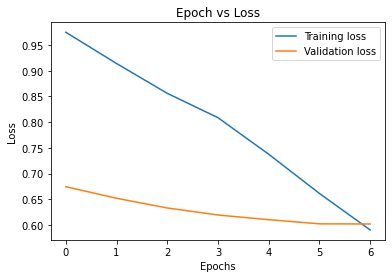

In [19]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Epoch vs Loss')
plt.legend()
plt.show()

In [20]:
predicted=[]
actuals=[]

inceptionModel.eval()

with torch.no_grad():
        for inputs, labels in test_iterator:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = inceptionModel(inputs)
            _, preds = torch.max(outputs, 1)

            preds = preds.detach().cpu().numpy()
            predicted.extend(preds)
            actuals.extend(labels.detach().cpu().numpy())

In [21]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

classes = ['Idiomatic', 'Literal']

print("Performance:")
# model's performance/
print('Classification Report')
print(classification_report(actuals, predicted, target_names=classes))

print("Accuracy: " + str(accuracy_score(actuals, predicted)))
print("F1 score: " + str(f1_score(actuals, predicted, average='macro')))

Performance:
Classification Report
              precision    recall  f1-score   support

   Idiomatic       0.78      0.73      0.76       242
     Literal       0.69      0.75      0.72       195

    accuracy                           0.74       437
   macro avg       0.74      0.74      0.74       437
weighted avg       0.74      0.74      0.74       437

Accuracy: 0.7391304347826086
F1 score: 0.7378110395351775


In [22]:
from sklearn.metrics import precision_score, recall_score

print("Precision: " + str(precision_score(actuals, predicted)))
print("Recall: " + str(recall_score(actuals, predicted)))

Precision: 0.6919431279620853
Recall: 0.7487179487179487
